In [2]:
#einops
from einops import rearrange, einsum
import torch
import matplotlib.pyplot as plt

In [3]:
images = torch.randn(64, 128, 128, 3) # (batch, height, width, channel)
dim_by = torch.linspace(start=0.0, end=1.0, steps=10)

In [4]:
dimmed_images = einsum(
images, dim_by,
"batch height width channel, dim_value -> batch dim_value height width channel"
)

In [5]:
dim_by.shape

torch.Size([10])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.0034013..4.591358].


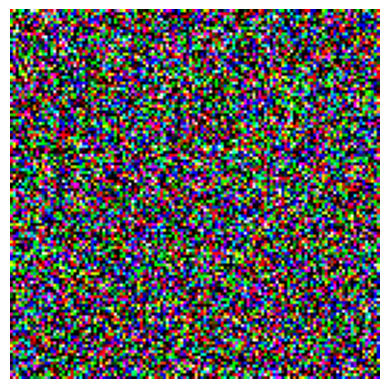

In [6]:
plt.imshow(images[0])
plt.axis("off")
plt.show()

In [7]:
dimmed_images[0,0].shape

torch.Size([128, 128, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.88964474..1.0203018].


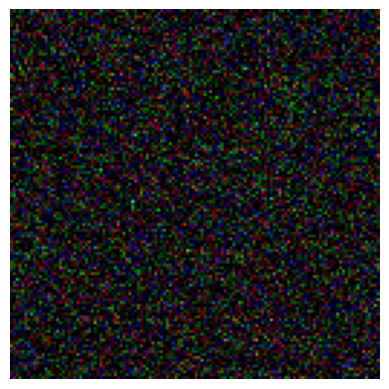

In [8]:
plt.imshow(dimmed_images[0,2])
plt.axis("off")
plt.show()

In [9]:
# Initialization
d_in = 32
d_out = d_in * 4

vocab_size = 100
d_model = 2048

w1 = torch.randn(d_in,d_out) * ((2/(d_in + d_out)))**0.5
print(w1.shape, w1.mean(), w1.var())

embd = torch.randn(vocab_size, d_model)




torch.Size([32, 128]) tensor(-0.0008) tensor(0.0124)


In [10]:
# Now I have to remember that if i want a given var i need to scale by the sqrt of that value

a = torch.randn(10000) * 10 # var( num * x) -> num^2 var(x)
a.var()

tensor(100.8938)

In [11]:
w1 = torch.empty(d_in, d_out)
std = (2 / (d_in + d_out))**0.5
torch.nn.init.trunc_normal_(
   w1,
   mean=0,
   std=std,
   a=-3 * std,
   b=3 * std
)

tensor([[-0.0170,  0.0635, -0.1135,  ..., -0.0454,  0.0989,  0.1448],
        [ 0.1576, -0.2909,  0.2158,  ..., -0.0736, -0.0483, -0.0779],
        [-0.0393,  0.0833, -0.0495,  ...,  0.2091,  0.1553,  0.1635],
        ...,
        [-0.1188, -0.0812, -0.0597,  ..., -0.2544,  0.0244, -0.1457],
        [ 0.0864, -0.0451, -0.0682,  ..., -0.0874,  0.0327,  0.0123],
        [-0.0494,  0.0767, -0.2673,  ..., -0.1413, -0.0180,  0.0506]])

In [12]:
def get_var(x):
   #To get the variance i firstly need to compute the mean
   mean = x.mean()

   summed_variance = 0
   for i in range(len(x)):
      summed_variance += (x[i] - mean)**2
   return summed_variance/(len(x) -1)

get_var(a), a.var()

   

(tensor(100.8935), tensor(100.8938))

In [13]:
vocab_size = 50
emb_dim = 500
batch_size = 10
sequence_length = 32
embedding_table = torch.randn(vocab_size,emb_dim)

token_ids = torch.randint(low = 0, high = vocab_size-1, size = (batch_size, sequence_length))
token_ids.shape

torch.Size([10, 32])

In [14]:
token_ids[0:2]

tensor([[29, 26,  1, 48, 17, 26,  6, 28, 48, 31, 10, 28, 28, 40,  5, 27, 47, 33,
         15, 26, 48, 26, 35, 24, 39, 21,  1, 38, 30,  8, 18, 13],
        [43, 39,  6, 39, 37, 35, 38, 48, 43, 31, 33,  7, 15, 44,  6, 11, 29,  1,
          0,  7, 11, 23, 28,  7, 20, 18,  4, 10, 36, 28, 47,  1]])

In [15]:
embedding_table[token_ids[0:2]].shape

torch.Size([2, 32, 500])

In [16]:
dim = 500
x = torch.randn((batch_size,sequence_length, dim))
x.shape

torch.Size([10, 32, 500])

In [17]:
rms = (x ** 2).mean(dim= -1, keepdim=True)**0.5

In [18]:
rms

tensor([[[1.0357],
         [0.9805],
         [1.0505],
         [0.9992],
         [1.0397],
         [1.0283],
         [1.0566],
         [0.9687],
         [0.9681],
         [1.0160],
         [1.0146],
         [0.9959],
         [1.0118],
         [0.9508],
         [0.9976],
         [0.9656],
         [1.0635],
         [0.9830],
         [0.9940],
         [1.0391],
         [1.0091],
         [0.9723],
         [1.0084],
         [1.0293],
         [0.9777],
         [1.0139],
         [1.0123],
         [0.9460],
         [0.9577],
         [1.0463],
         [0.9842],
         [0.9865]],

        [[1.0226],
         [0.9873],
         [0.9707],
         [0.9883],
         [0.9813],
         [1.0025],
         [0.9552],
         [1.0364],
         [0.9961],
         [0.9700],
         [1.0351],
         [1.0441],
         [1.0198],
         [0.9944],
         [1.1107],
         [0.9613],
         [0.9719],
         [0.9901],
         [1.0283],
         [1.0132],
         [

In [19]:
x_normalized = x / (rms + 1e-5)

In [20]:
rms.shape

torch.Size([10, 32, 1])

In [21]:
x_normalized.shape

torch.Size([10, 32, 500])

In [22]:
gain = torch.zeros(dim)

In [23]:
(x_normalized * gain)

tensor([[[-0., 0., -0.,  ..., 0., -0., 0.],
         [-0., -0., 0.,  ..., -0., 0., 0.],
         [0., -0., -0.,  ..., -0., -0., -0.],
         ...,
         [0., 0., -0.,  ..., 0., 0., -0.],
         [-0., -0., -0.,  ..., 0., -0., 0.],
         [-0., -0., -0.,  ..., 0., 0., -0.]],

        [[0., -0., -0.,  ..., -0., -0., 0.],
         [0., -0., 0.,  ..., 0., -0., 0.],
         [0., 0., 0.,  ..., -0., 0., -0.],
         ...,
         [-0., -0., -0.,  ..., -0., 0., 0.],
         [0., 0., -0.,  ..., -0., -0., 0.],
         [-0., 0., -0.,  ..., 0., -0., 0.]],

        [[-0., -0., -0.,  ..., -0., 0., 0.],
         [0., -0., 0.,  ..., -0., 0., 0.],
         [-0., 0., 0.,  ..., -0., -0., 0.],
         ...,
         [0., 0., -0.,  ..., -0., -0., 0.],
         [0., 0., -0.,  ..., -0., 0., -0.],
         [0., 0., -0.,  ..., -0., 0., 0.]],

        ...,

        [[-0., 0., 0.,  ..., -0., -0., 0.],
         [0., -0., 0.,  ..., 0., 0., -0.],
         [0., -0., 0.,  ..., -0., -0., 0.],
         ...,

In [24]:
a = torch.ones(2,2) * 1
b = torch.ones (2,1) * 3
b[0] = 5
a * b

tensor([[5., 5.],
        [3., 3.]])

In [25]:
def rotate_2d_vector(x, i, theta):
   R = torch.tensor([[torch.cos(theta * i),  torch.sin(i * theta)], [- torch.sin(i * theta), torch.cos(i * theta)]])
   return R @ x
   
   

NameError: name 'v_rot' is not defined

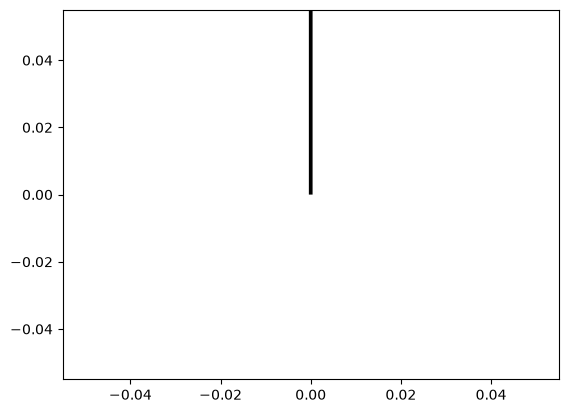

In [26]:
v = torch.tensor([0.0, 4.0])

v_rot1 = rotate_2d_vector(v, 1, torch.tensor(torch.pi/4))
plt.quiver(
   0, 0,
   v[0], v[1],
   angles="xy",
   scale_units="xy",
   scale=1
)

plt.quiver(
   0, 0,
   v_rot[0], v_rot[1],
   angles="xy",
   scale_units="xy",
   scale=1
)

plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.axhline(0)
plt.axvline(0)
plt.gca().set_aspect("equal")
plt.grid()

plt.show()

In [ ]:
d_k = 128
i = [1,2,3]
theta = 10000



angle = lambda i, k: torch.tensor(i / (theta ** ((2 * k - 2) / d_k)))

In [ ]:
print(angle(1, 1))
print(angle(1, 2))
print(angle(3, 10))

1.0
0.8659643233600653
0.8215258902793083


In [ ]:
def rotate_4d_vector(x, i, theta):
   R = torch.tensor([[torch.cos(theta * i),  torch.sin(i * theta), 0, 0], [ - torch.sin(i * theta), torch.cos(i * theta),0,0]])
   return R @ x

In [ ]:
x = torch.tensor([1.0,1.0, 2.0,2.0])
rotate_4d_vector(x, torch.tensor((1)), torch.tensor(1.5))

tensor([ 1.0682, -1.8535])

In [ ]:
x = torch.tensor(range(128))
x = rearrange(
   x,
   "... (couple_index pair) -> ... couple_index pair",
   pair=2
)
x.shape



torch.Size([64, 2])

In [42]:

angle = lambda i, k: torch.tensor(
   i / (theta ** ((2 * k - 2) / d_k))
)

cos_vec = torch.stack([
   torch.stack([
      torch.cos(angle(i, k))
      for k in range(1,3)
   ])
   for i in range(64)
])

sin_vec = torch.stack([
   torch.stack([
      torch.sin(angle(i, k))
      for k in range(1,3)
   ])
   for i in range(64)
])

In [43]:
cos_vec.shape, sin_vec.shape

(torch.Size([64, 2]), torch.Size([64, 2]))

In [ ]:
x.shape

torch.Size([64, 2])

In [45]:
a = x[...,0]
b = x [...,1]
a.shape, a
a_rotated = a * cos_vec + b * sin_vec
b_rotated = -a * sin_vec + b * cos_vec

RuntimeError: The size of tensor a (32) must match the size of tensor b (2) at non-singleton dimension 1

In [ ]:
a_rotated = a * cos_vec + b * sin_vec

In [28]:
import torch

In [37]:
d_k = 128
theta = 1000
token_index = range(10)
cos_vec = torch.stack([
   torch.stack([
      torch.cos(angle(i, k))
      for k in range(int(d_k/2))
   ])
   for i in token_index
])

In [38]:
cos_vec.shape

torch.Size([10, 64])

In [40]:
a_rotated.shape

NameError: name 'a_rotated' is not defined

In [46]:
a = torch.randn(3, 4) #(T, couple_index)
b = torch.randn(3, 4)


In [52]:
merged = torch.stack((a,b), dim = -1)

In [53]:
merged.shape

torch.Size([3, 4, 2])

In [55]:
result = rearrange(merged, "... T couple_index couple-> ... T (couple_index couple)")

In [56]:
result.shape

torch.Size([3, 8])

In [89]:
def forward( x: torch.Tensor, token_positions: torch.Tensor, max_seq_len) -> torch.Tensor :
   d_k = 128
   theta = 1000
   """
   Process
   an input tensor of shape (..., seq_len, d_k) and return a tensor of the same shape. Note
   that you should tolerate 𝑥 with an arbitrary number of batch dimensions. You should assume
   that the token positions are a tensor of shape (..., seq_len) specifying the token positions of
   𝑥 along the sequence dimension
   """


   # I receive (..., T, dk) where T is an arbitrary sequence length and it's not fixed, the position of each token
   # is specified in the token_position tensor (..., T) so for each embedding vector of dimension C i have also 
   # the corresponding i position
   
   # I assume that x is already a query or a key vector and I have to rotate it. I have to assert that it's d_k dimension
   # it's a multiple of 2, given that I am going to rotate in couples. That means that i am going to create couples of 
   # coordinate that are going to be rotate at different speeds, like take for example x = (x1, x2, x3, x4)
   # The couple (x1, x2) is going to be rotated using a certain coefficient, and instead (x3, x4) is going to be rotated 
   # at another speed. Why this difference in speed rotation? to increase entropy.
   
   # I need to build the rotation matrix, the rotation applied to a given couple k of coordinate of a given token ith
   #  is dependent on the ith index and on the couple k. 
   
   angle = lambda token_i, couple_j: token_i / (theta ** ((2 * couple_j - 2) / d_k))

   # I need to find a way in which I can pack the rotation into a matrix - vector mul
   x = rearrange(x, "... (couple_index len) -> ... couple_index len", len = 2)

   # x.shape -> (..., couple_index, 2)
   
   cos_vec_table = torch.stack([torch.stack([torch.cos(torch.tensor(angle(i, k))) for k in range(1, int(d_k//2) + 1) ]) for i in range(max_seq_len)])
   sin_vec_table = torch.stack([torch.stack([torch.sin(torch.tensor(angle(i, k))) for k in range(1, int(d_k//2) + 1) ]) for i in range(max_seq_len)])

   cos_vec = cos_vec_table[token_positions]
   sin_vec = sin_vec_table[token_positions]
   a, b = x[..., 0], x [..., 1]
   print(cos_vec.shape, sin_vec.shape, x.shape, a.shape, b.shape)
   
   a_rotated = a * cos_vec - b * sin_vec
   b_rotated = a * sin_vec + b * cos_vec

   # Merge back them a = (..., T, couple_index) +  -> (..., T, 2)
   #                 b = (..., T, couple_index) ^
   merged = torch.stack((a_rotated, b_rotated), dim = -1)

   # Now i can rearrange merged (..., T, couple_Index, 2) ---> (..., T, couple_index * 2)

   result = rearrange(merged, "... T couple_index couple-> ... T (couple_index couple)")


   return result

In [85]:
cos_vec_table = torch.stack([torch.stack([torch.cos(angle(i, k)) for k in range(1, int(d_k//2) + 1) ]) for i in range(max_seq_len)])
sin_vec_table = torch.stack([torch.stack([torch.sin(angle(i, k)) for k in range(1, int(d_k//2) + 1) ]) for i in range(max_seq_len)])

In [86]:
cos_vec_table.shape

torch.Size([1000, 64])

In [88]:
cos_vec_table[token_position].shape

torch.Size([4, 10, 64])

In [91]:
max_seq_len = 1000
token_position = torch.randint(size=(4, 10), high = 10)
x = torch.randint(size=(4, 10, 128), high = 1000)
result = forward(x, token_positions= token_position, max_seq_len=max_seq_len)

torch.Size([4, 10, 64]) torch.Size([4, 10, 64]) torch.Size([4, 10, 64, 2]) torch.Size([4, 10, 64]) torch.Size([4, 10, 64])


In [92]:
result.shape

torch.Size([4, 10, 128])

In [98]:
from torch import nn
class RotaryPositionalEmbedding(nn.Module):
   def __init__(self, theta: float, d_k: int, max_seq_len: int, device=None):
      self.theta = theta
      self.d_k = d_k
      self.max_seq_len = max_seq_len
      self.device = device

      # Pre process lookup tables
      angle = lambda token_i, couple_j: token_i / (self.theta ** ((2 * couple_j - 2) / self.d_k))
      self.cos_vec_table = torch.stack([torch.stack([torch.cos(torch.tensor(angle(i, k))) for k in range(1, int(d_k//2) + 1) ]) for i in range(max_seq_len)])
      self.sin_vec_table = torch.stack([torch.stack([torch.sin(torch.tensor(angle(i, k))) for k in range(1, int(d_k//2) + 1) ]) for i in range(max_seq_len)])
      
      
   def forward(self, x: torch.Tensor, token_positions: torch.Tensor) -> torch.Tensor :
      """
      Process
      an input tensor of shape (..., seq_len, d_k) and return a tensor of the same shape. Note
      that you should tolerate 𝑥 with an arbitrary number of batch dimensions. You should assume
      that the token positions are a tensor of shape (..., seq_len) specifying the token positions of
      𝑥 along the sequence dimension
      """


      # I receive (..., T, dk) where T is an arbitrary sequence length and it's not fixed, the position of each token
      # is specified in the token_position tensor (..., T) so for each embedding vector of dimension C i have also 
      # the corresponding i position
      
      # I assume that x is already a query or a key vector and I have to rotate it. I have to assert that it's d_k dimension
      # it's a multiple of 2, given that I am going to rotate in couples. That means that i am going to create couples of 
      # coordinate that are going to be rotate at different speeds, like take for example x = (x1, x2, x3, x4)
      # The couple (x1, x2) is going to be rotated using a certain coefficient, and instead (x3, x4) is going to be rotated 
      # at another speed. Why this difference in speed rotation? to increase entropy.
      
      # I need to build the rotation matrix, the rotation applied to a given couple k of coordinate of a given token ith
      #  is dependent on the ith index and on the couple k. 
      
  

      # I need to find a way in which I can pack the rotation into a matrix - vector mul
      x = rearrange(x, "... d_k -> ... couple_index len", len = 2)

      # x.shape -> (..., couple_index, 2)
      

      a, b = x[..., 0], x [..., 1]

      cos_vec = self.cos_vec_table[token_positions]
      sin_vec = self.sin_vec_table[token_positions]

      a_rotated = a * cos_vec - b * sin_vec
      b_rotated = a * sin_vec + b * cos_vec

      # Merge back them a = (..., T, couple_index) +  -> (..., T, 2)
      #                 b = (..., T, couple_index) ^
      merged = torch.stack((a_rotated, b_rotated), dim = -1)

      # Now i can rearrange merged (..., T, couple_Index, 2) ---> (..., T, couple_index * 2)

      result = rearrange(merged, "... T couple_index couple-> ... T (couple_index couple)")


      return result

In [100]:

rot = RotaryPositionalEmbedding(1, 2, 2)

In [104]:
rot.forward([1,2], [1,1])

RuntimeError: Tensor type unknown to einops <class 'int'>

In [149]:
def softmax(x, dimension_i):
   """
   Apply the classic softmax over a tensor on the ith dimension_i, for numerical stability
   it's necessary to subtract the max on that dimension before applying softmax.
   
   """
   
   x = x - torch.max(x, dim = dimension_i, keepdim=True).values
   
   return torch.exp(x) / torch.sum(torch.exp(x), dim = -1, keepdim=True)
   
   

In [145]:
x = torch.randn(1, 2, 2)
dimension_i = -1

In [148]:
x = x - torch.max(x, dim = dimension_i, keepdim=True).values
torch.exp(x).shape
torch.exp(x) / torch.sum(torch.exp(x), dim = -1, keepdim=True)

tensor([[[0.9877, 0.0123],
         [0.6843, 0.3157]]])

In [168]:
B = 1
T = 10
d_k = 10000
key = torch.randn((B,T,d_k))
query = torch.randn((B,T,d_k))



In [169]:
h = einsum(query, key, "... seq_len1 d_k, ... seq_len2 d_k -> ... seq_len1 seq_len2") 

In [170]:
h.shape

torch.Size([1, 10, 10])

In [171]:
torch.var(h, dim = -1)

tensor([[12035.2637,  3215.0669, 11513.2500, 11554.0176,  6130.5986, 13378.8135,
          3077.5471, 10756.6904,  4598.6445, 17873.4473]])

In [ ]:
h = h /  torch.sqrt(torch.tensor(d_k))

In [173]:
torch.var(h, dim = -1)

tensor([[1.2035, 0.3215, 1.1513, 1.1554, 0.6131, 1.3379, 0.3078, 1.0757, 0.4599,
         1.7873]])

In [175]:
query.shape[-1]

10000

In [176]:
value =  torch.randn((B,T,d_k))

In [177]:
weights = softmax(h, dimension_i = -1)

attns = einsum(weights, value, "... seq_len1 seq_len2, ... seq_len3 d_v -> ... seq_len1 d_v")

In [178]:
attns.shape

torch.Size([1, 10, 10000])

In [181]:
A = torch.randn((2,2))
B = torch.randn((2,2))
C = einsum(A,B, "... seq1 seq2, ... seq3 d_v -> ... seq1 d_v")
C_mat = A @ B

In [182]:
C.shape, C_mat.shape

(torch.Size([2, 2]), torch.Size([2, 2]))

In [183]:
C


tensor([[-0.4730, -0.0966],
        [ 2.0049,  0.4095]])

In [184]:
C_mat

tensor([[1.2883, 0.6524],
        [1.7901, 0.5667]])

In [188]:
assert 8 % 3== 0

AssertionError: 